<a href="https://colab.research.google.com/github/ImanSarah/Deep-Vision-AI-Workshop/blob/main/BrainTumorDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import zipfile

zip_path = "/content/archive (21).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
img_size = 128
batch_size = 32

train = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train.flow_from_directory(
    "dataset/brain_tumor_dataset",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary",
    subset="training"
)

val_data = train.flow_from_directory(
    "dataset/brain_tumor_dataset",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [11]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32,(3,3),activation='relu',
                           input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),

    tf.keras.layers.Dense(1,activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [13]:
model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 985ms/step - accuracy: 0.6847 - loss: 0.7445 - val_accuracy: 0.7200 - val_loss: 0.5220
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 655ms/step - accuracy: 0.7685 - loss: 0.5040 - val_accuracy: 0.7600 - val_loss: 0.5365
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 905ms/step - accuracy: 0.8473 - loss: 0.3736 - val_accuracy: 0.7400 - val_loss: 0.5298
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 652ms/step - accuracy: 0.8916 - loss: 0.2791 - val_accuracy: 0.8000 - val_loss: 0.4366
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 714ms/step - accuracy: 0.9360 - loss: 0.1895 - val_accuracy: 0.8200 - val_loss: 0.4255
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 795ms/step - accuracy: 0.9754 - loss: 0.0876 - val_accuracy: 0.7800 - val_loss: 0.4861
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 660ms/step - accuracy: 0.9951 - loss: 0.0403 - val_accuracy: 0.8400 - val_loss: 0.4787
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 859ms/step - accuracy: 0.9951 - loss: 0.0218 - val_accuracy: 0.8400 - val_loss:

In [14]:
model.save("brain_tumor_model.h5")

In [15]:
model = tf.keras.models.load_model("brain_tumor_model.h5")

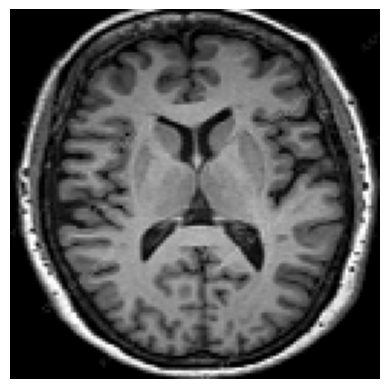

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
No Brain Tumor


In [17]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(
    "/content/healthybrain.png",
    target_size=(128,128)
)

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = image.img_to_array(img)
img_array = img_array/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Brain Tumor Detected")
else:
    print("No Brain Tumor")

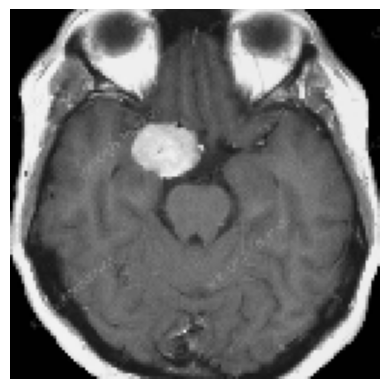

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Brain Tumor Detected


In [18]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(
    "/content/my_test_image.png.png",
    target_size=(128,128)
)

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = image.img_to_array(img)
img_array = img_array/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Brain Tumor Detected")
else:
    print("No Brain Tumor")